In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("ecommerce_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 30)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status,Order_DayOfWeek,Is_Loss,Revenue_Per_Unit,Discount_Category
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,32.91,2.25,Economy,4,Google Pay,Delivered,2,0,520.400000,No Discount
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,16.41,4.72,Economy,5,Credit Card,Delivered,0,0,16.940000,High (21-30%)
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,33.11,13.28,Standard,8,Credit Card,Processing,3,0,241.300000,No Discount
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,43.60,31.11,Express,16,Google Pay,Processing,4,0,130.900000,No Discount
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,33.63,8.44,Standard,5,Debit Card,Delivered,6,0,59.606667,Medium (11-20%)


In [4]:
df.info()
print("\nNull values:", df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           10000 non-null  str    
 1   Order_Date         10000 non-null  str    
 2   Year               10000 non-null  int64  
 3   Month              10000 non-null  int64  
 4   Quarter            10000 non-null  str    
 5   Season             10000 non-null  str    
 6   Customer_ID        10000 non-null  str    
 7   Customer_Gender    10000 non-null  str    
 8   Customer_Segment   10000 non-null  str    
 9   Region             10000 non-null  str    
 10  Country            10000 non-null  str    
 11  Category           10000 non-null  str    
 12  Sub_Category       10000 non-null  str    
 13  Product_Name       10000 non-null  str    
 14  Unit_Price         10000 non-null  float64
 15  Quantity           10000 non-null  int64  
 16  Discount           10000 non-null 

In [5]:
print("Target Variable: Is_Loss")
print(df['Is_Loss'].value_counts())
print(f"Class balance: {df['Is_Loss'].mean()*100:.1f}% loss orders")

Target Variable: Is_Loss
Is_Loss
0    8662
1    1338
Name: count, dtype: int64
Class balance: 13.4% loss orders


In [6]:
DROP_COLS = ['Is_Loss', 'Order_ID', 'Customer_ID', 'Order_Date',
             'Product_Name', 'Order_DayOfWeek', 'Discount_Category']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = X.select_dtypes(include=[np.number])
y = df['Is_Loss']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeatures:", list(X.columns))

Feature matrix X shape: (10000, 12)
Target vector y shape: (10000,)

Features: ['Year', 'Month', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days', 'Revenue_Per_Unit']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples (80%)")
print(f"Test set     : {X_test.shape[0]} samples (20%)")
print("\nTrain target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

Training set : 8000 samples (80%)
Test set     : 2000 samples (20%)

Train target distribution:
Is_Loss
0    6930
1    1070
Name: count, dtype: int64

Test target distribution:
Is_Loss
0    1732
1     268
Name: count, dtype: int64


In [8]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs'))
])

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions on test set:")
print(f"First 10 predicted : {y_pred[:10]}")
print(f"First 10 actual    : {y_test.values[:10]}")

Predictions on test set:
First 10 predicted : [0 0 0 0 0 0 0 0 0 0]
First 10 actual    : [0 0 0 0 0 0 0 0 0 0]


In [10]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print("=" * 45)
print("MODEL PERFORMANCE")
print("=" * 45)
print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Test Accuracy     : {test_acc*100:.2f}%")
diff = train_acc - test_acc
print(f"Difference        : {diff*100:.2f}%")
if diff > 0.05:
    print("WARNING: Possible overfitting!")
else:
    print("Model generalizes well.")

MODEL PERFORMANCE
Training Accuracy : 99.69%
Test Accuracy     : 99.65%
Difference        : 0.04%
Model generalizes well.


In [11]:
print("CLASSIFICATION REPORT")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=['Profitable', 'Loss']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Profitable       1.00      1.00      1.00      1732
        Loss       0.99      0.99      0.99       268

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



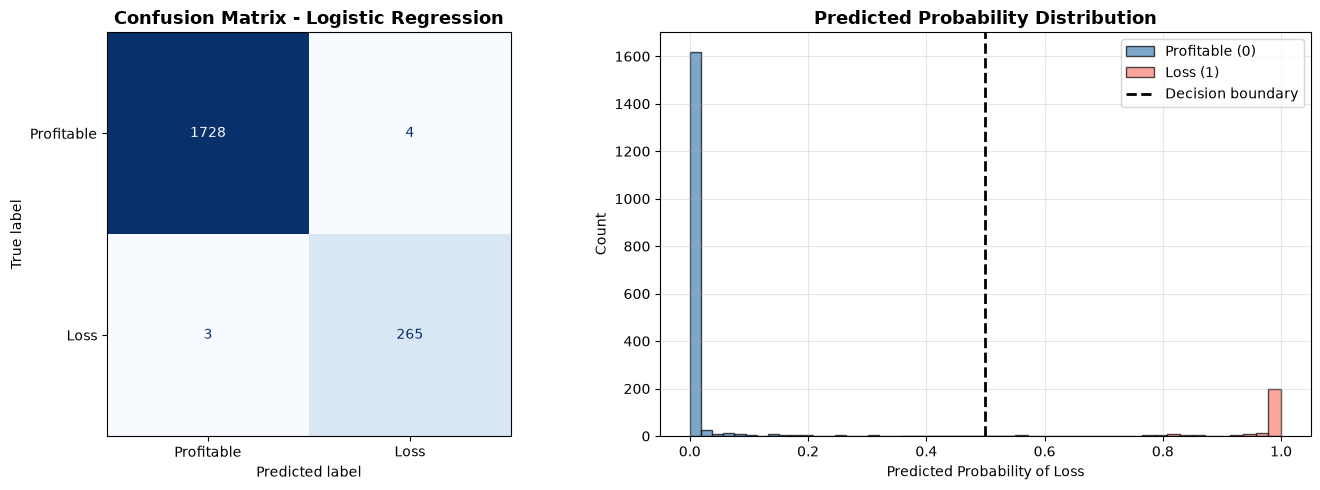

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Profitable', 'Loss'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')

axes[1].hist(y_prob[y_test==0], bins=30, alpha=0.7, color='steelblue',
             edgecolor='black', label='Profitable (0)')
axes[1].hist(y_prob[y_test==1], bins=30, alpha=0.7, color='salmon',
             edgecolor='black', label='Loss (1)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
axes[1].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Loss')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

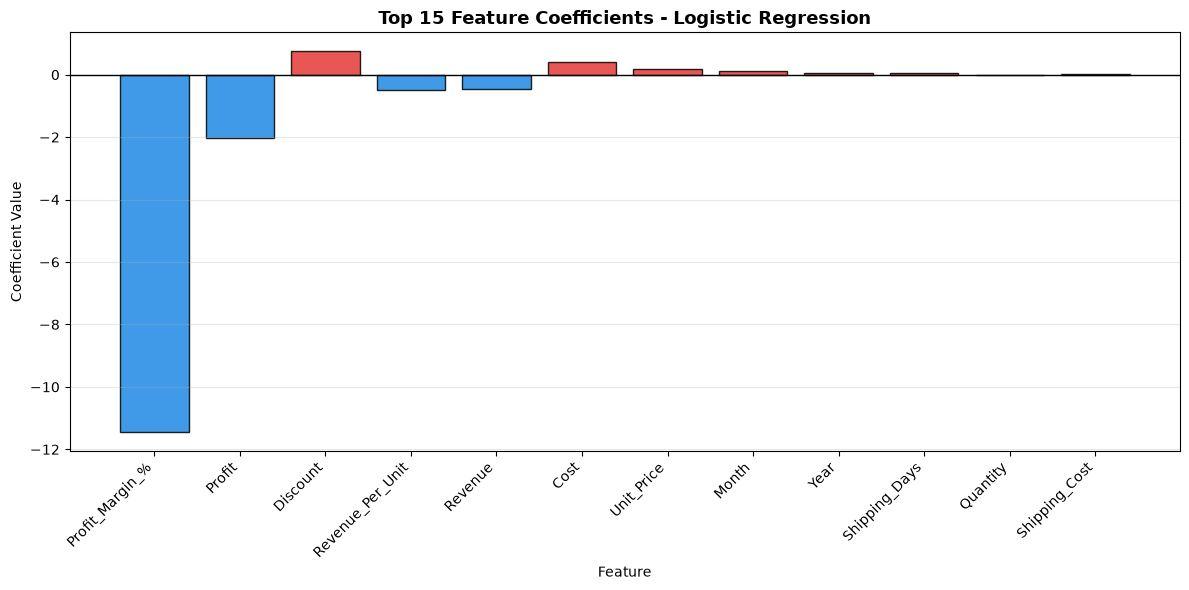

In [13]:
feature_names = X.columns.tolist()
coefficients = model.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
colors = ['#E53935' if c > 0 else '#1E88E5' for c in coef_df['Coefficient'][:15]]
plt.bar(coef_df['Feature'][:15], coef_df['Coefficient'][:15],
        color=colors, edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Coefficients - Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("=" * 55)
print("CONCLUSIONS")
print("=" * 55)
print("1. Baseline Logistic Regression model trained successfully.")
print(f"2. Test Accuracy: {test_acc*100:.2f}%")
print("3. Data leakage prevented: split BEFORE scaler fitting.")
print("4. random_state=42 ensures full reproducibility.")
print("5. Stratified split preserves class balance in both sets.")
print("6. Next step: compare with Random Forest for improvement.")

CONCLUSIONS
1. Baseline Logistic Regression model trained successfully.
2. Test Accuracy: 99.65%
3. Data leakage prevented: split BEFORE scaler fitting.
4. random_state=42 ensures full reproducibility.
5. Stratified split preserves class balance in both sets.
6. Next step: compare with Random Forest for improvement.
